### 实验过程中的问题，
第一次，尝试计算每个月代表晴天的中午位置偏移量，但发现在整天时段下午出现大偏移；
第二次，尝试计算每个月代表晴天的多个位置偏移量，生成台账，并验证泛化性，效果可以。

### 基础库、计算函数

In [64]:
import tarfile
import cv2
import os
import datetime as dt
import numpy as np
import matplotlib.pyplot as plt
from math import radians, degrees, sin, cos, acos, atan, pi,tan
import calendar
import random

def doy_tod_conv(date_and_time, longitude=-122.174199, time_zone_center_longitude=-120):
    # 原作者的时间转换逻辑（保持不变，处理夏令时和经度偏差）
    pst_center_longitude = time_zone_center_longitude 
    loc_longitude = longitude 
    correction = np.abs(60/15*(loc_longitude - pst_center_longitude))
    min_correction = int(correction) 
    sec_correction = int((correction - min_correction)*60)  
    if date_and_time.minute<=min_correction:
        date_and_time= date_and_time.replace(hour = date_and_time.hour-1, minute=60+date_and_time.minute-min_correction-1, second=60-sec_correction)
    else:
        date_and_time = date_and_time.replace(minute=date_and_time.minute-min_correction-1, second=60-sec_correction)
    
    time_of_day = date_and_time.hour * 3600 + date_and_time.minute * 60 + date_and_time.second
    
    months = [31,28,31,30,31,30,31,31,30,31,30,31] 
    if (date_and_time.year % 4 == 0) and (date_and_time.year % 100 != 0 or date_and_time.year % 400 ==0 ):
        months[1] = 29 
    day_of_year = sum(months[:date_and_time.month-1]) + date_and_time.day
    
    #处理夏令时（-3600s），但是看输出有问题，注释掉试试
    dst_start_day = sum(months[:2]) + calendar.monthcalendar(date_and_time.year,3)[1][6] 
    dst_end_day = sum(months[:10]) + calendar.monthcalendar(date_and_time.year,11)[0][6]
    if day_of_year >= dst_start_day and day_of_year < dst_end_day:
        time_of_day = time_of_day - 3600
    

    return day_of_year, time_of_day

def solar_angle(times, latitude=37.424107, longitude=-122.174199, time_zone_center_longitude=-120):
    # 计算太阳的方位角和天顶角
    day_of_year, time_of_day = doy_tod_conv(times, longitude, time_zone_center_longitude)
    latitude = radians(latitude) 

    # ==========================================
    # 🌟 核心升级：均时差 (Equation of Time) 分钟修正项
    # 将机械的手表时间，修正为宇宙真实的“太阳时间”
    # ==========================================
    # B 是以弧度表示的平近点角 (2019年春分点在第 80 天)
    B = 2 * pi * (day_of_year - 80) / 365.0
    
    # 国际标准 EoT 近似公式 (计算出需要补偿的分钟数)
    eot_minutes = 9.87 * sin(2 * B) - 7.53 * cos(B) - 1.5 * sin(B)
    
    # 将算出的分钟数转化为秒，加到原有的 time_of_day 上！
    time_of_day_corrected = time_of_day + (eot_minutes * 60)
    # ==========================================

    alpha = 2*pi*(time_of_day_corrected-43200)/86400 #计算真实太阳时
    delta = radians(23.44*sin(radians((360/365.25)*(day_of_year-80))))
    chi = acos(sin(delta)*sin(latitude)+cos(delta)*cos(latitude)*cos(alpha))
    
    tan_xi = sin(alpha)/(sin(latitude)*cos(alpha)-cos(latitude)*tan(delta)) 
    if alpha>0 and tan_xi>0:
        xi = pi+atan(tan_xi)
    elif alpha>0 and tan_xi<0:
        xi = 2*pi+atan(tan_xi)
    elif alpha<0 and tan_xi>0:
        xi = atan(tan_xi)
    else:
        xi = pi+atan(tan_xi)
    return degrees(xi), degrees(chi)

### 查看相机正常工作天数

In [61]:
tar_folder = "2019StanFord_image"  

def check_missing_camera_days(tar_filename):
    tar_path = os.path.join(tar_folder, tar_filename)
    if not os.path.exists(tar_path):
        print(f"❌ 找不到压缩包: {tar_path}")
        return
        
    print(f"🔍 正在扫描压缩包 {tar_filename} ...")
    
    with tarfile.open(tar_path, "r") as tar:
        members = tar.getmembers()
        
        # 提取压缩包里所有出现过的日期 (YYYYMMDD)
        available_days = set()
        for m in members:
            if m.name.endswith('.jpg'):
                filename = os.path.basename(m.name)
                available_days.add(filename[:8])
                
        if not available_days:
            print("这个包里一张 jpg 图片都没有！")
            return
            
        # 随便取一个日期，解析出当前的年份和月份
        sample_day = list(available_days)[0]
        year = int(sample_day[:4])
        month = int(sample_day[4:6])
        
        # 获取这个月到底有多少天 (比如 2019年2月是28天，5月是31天)
        _, num_days_in_month = calendar.monthrange(year, month)
        
        # 生成这个月的“满勤日历”集合
        full_month_days = set([f"{year:04d}{month:02d}{day:02d}" for day in range(1, num_days_in_month + 1)])
        
        # 两者相减，得出缺勤的日期！
        missing_days = sorted(list(full_month_days - available_days))
        
        print(f"📅 统计月份: {year}年{month}月 (共 {num_days_in_month} 天)")
        print(f"✅ 相机正常工作天数: {len(available_days)} 天")
        print(f"❌ 相机缺失/未记录天数: {len(missing_days)} 天")
        
        if missing_days:
            print("👉 相机没有留下任何图片的日期如下:")
            # 每行打印 7 个日期，排版美观
            for i in range(0, len(missing_days), 7):
                print(missing_days[i:i+7])
        else:
            print("🎉 太棒了，这个月相机满勤，一天都没落下！")
    print("-" * 50)

# ================= 运行区 =================
tar_1= "2019_01_images_raw.tar" 
tar_2 = "2019_02_images_raw.tar" 
tar_5 = "2019_05_images_raw.tar" 
tar_6 = "2019_06_images_raw.tar" 
tar_7 = "2019_07_images_raw.tar" 
tar_8 = "2019_08_images_raw.tar" 
tar_9= "2019_09_images_raw.tar" 
tar_10= "2019_10_images_raw.tar" 

check_missing_camera_days(tar_1)
check_missing_camera_days(tar_2)
check_missing_camera_days(tar_5)
check_missing_camera_days(tar_6)
check_missing_camera_days(tar_7)
check_missing_camera_days(tar_8)
check_missing_camera_days(tar_9)
check_missing_camera_days(tar_10)

🔍 正在扫描压缩包 2019_01_images_raw.tar ...
📅 统计月份: 2019年1月 (共 31 天)
✅ 相机正常工作天数: 5 天
❌ 相机缺失/未记录天数: 26 天
👉 相机没有留下任何图片的日期如下:
['20190101', '20190102', '20190103', '20190104', '20190105', '20190106', '20190107']
['20190108', '20190109', '20190110', '20190111', '20190112', '20190113', '20190114']
['20190115', '20190116', '20190117', '20190118', '20190119', '20190120', '20190121']
['20190122', '20190123', '20190128', '20190129', '20190130']
--------------------------------------------------
🔍 正在扫描压缩包 2019_02_images_raw.tar ...
📅 统计月份: 2019年2月 (共 28 天)
✅ 相机正常工作天数: 6 天
❌ 相机缺失/未记录天数: 22 天
👉 相机没有留下任何图片的日期如下:
['20190207', '20190208', '20190209', '20190210', '20190211', '20190212', '20190213']
['20190214', '20190215', '20190216', '20190217', '20190218', '20190219', '20190220']
['20190221', '20190222', '20190223', '20190224', '20190225', '20190226', '20190227']
['20190228']
--------------------------------------------------
🔍 正在扫描压缩包 2019_05_images_raw.tar ...
📅 统计月份: 2019年5月 (共 31 天)
✅ 相机正常工作天数: 12 天
❌ 相

### 计算偏移台账

批量提取全天候物理畸变曲线...

 1月台账提取成功！采样点数: 39
 5月台账提取成功！采样点数: 22
 6月台账提取成功！采样点数: 47
 7月台账提取成功！采样点数: 46
 8月台账提取成功！采样点数: 47
 9月台账提取成功！采样点数: 46
 10月台账提取成功！采样点数: 40


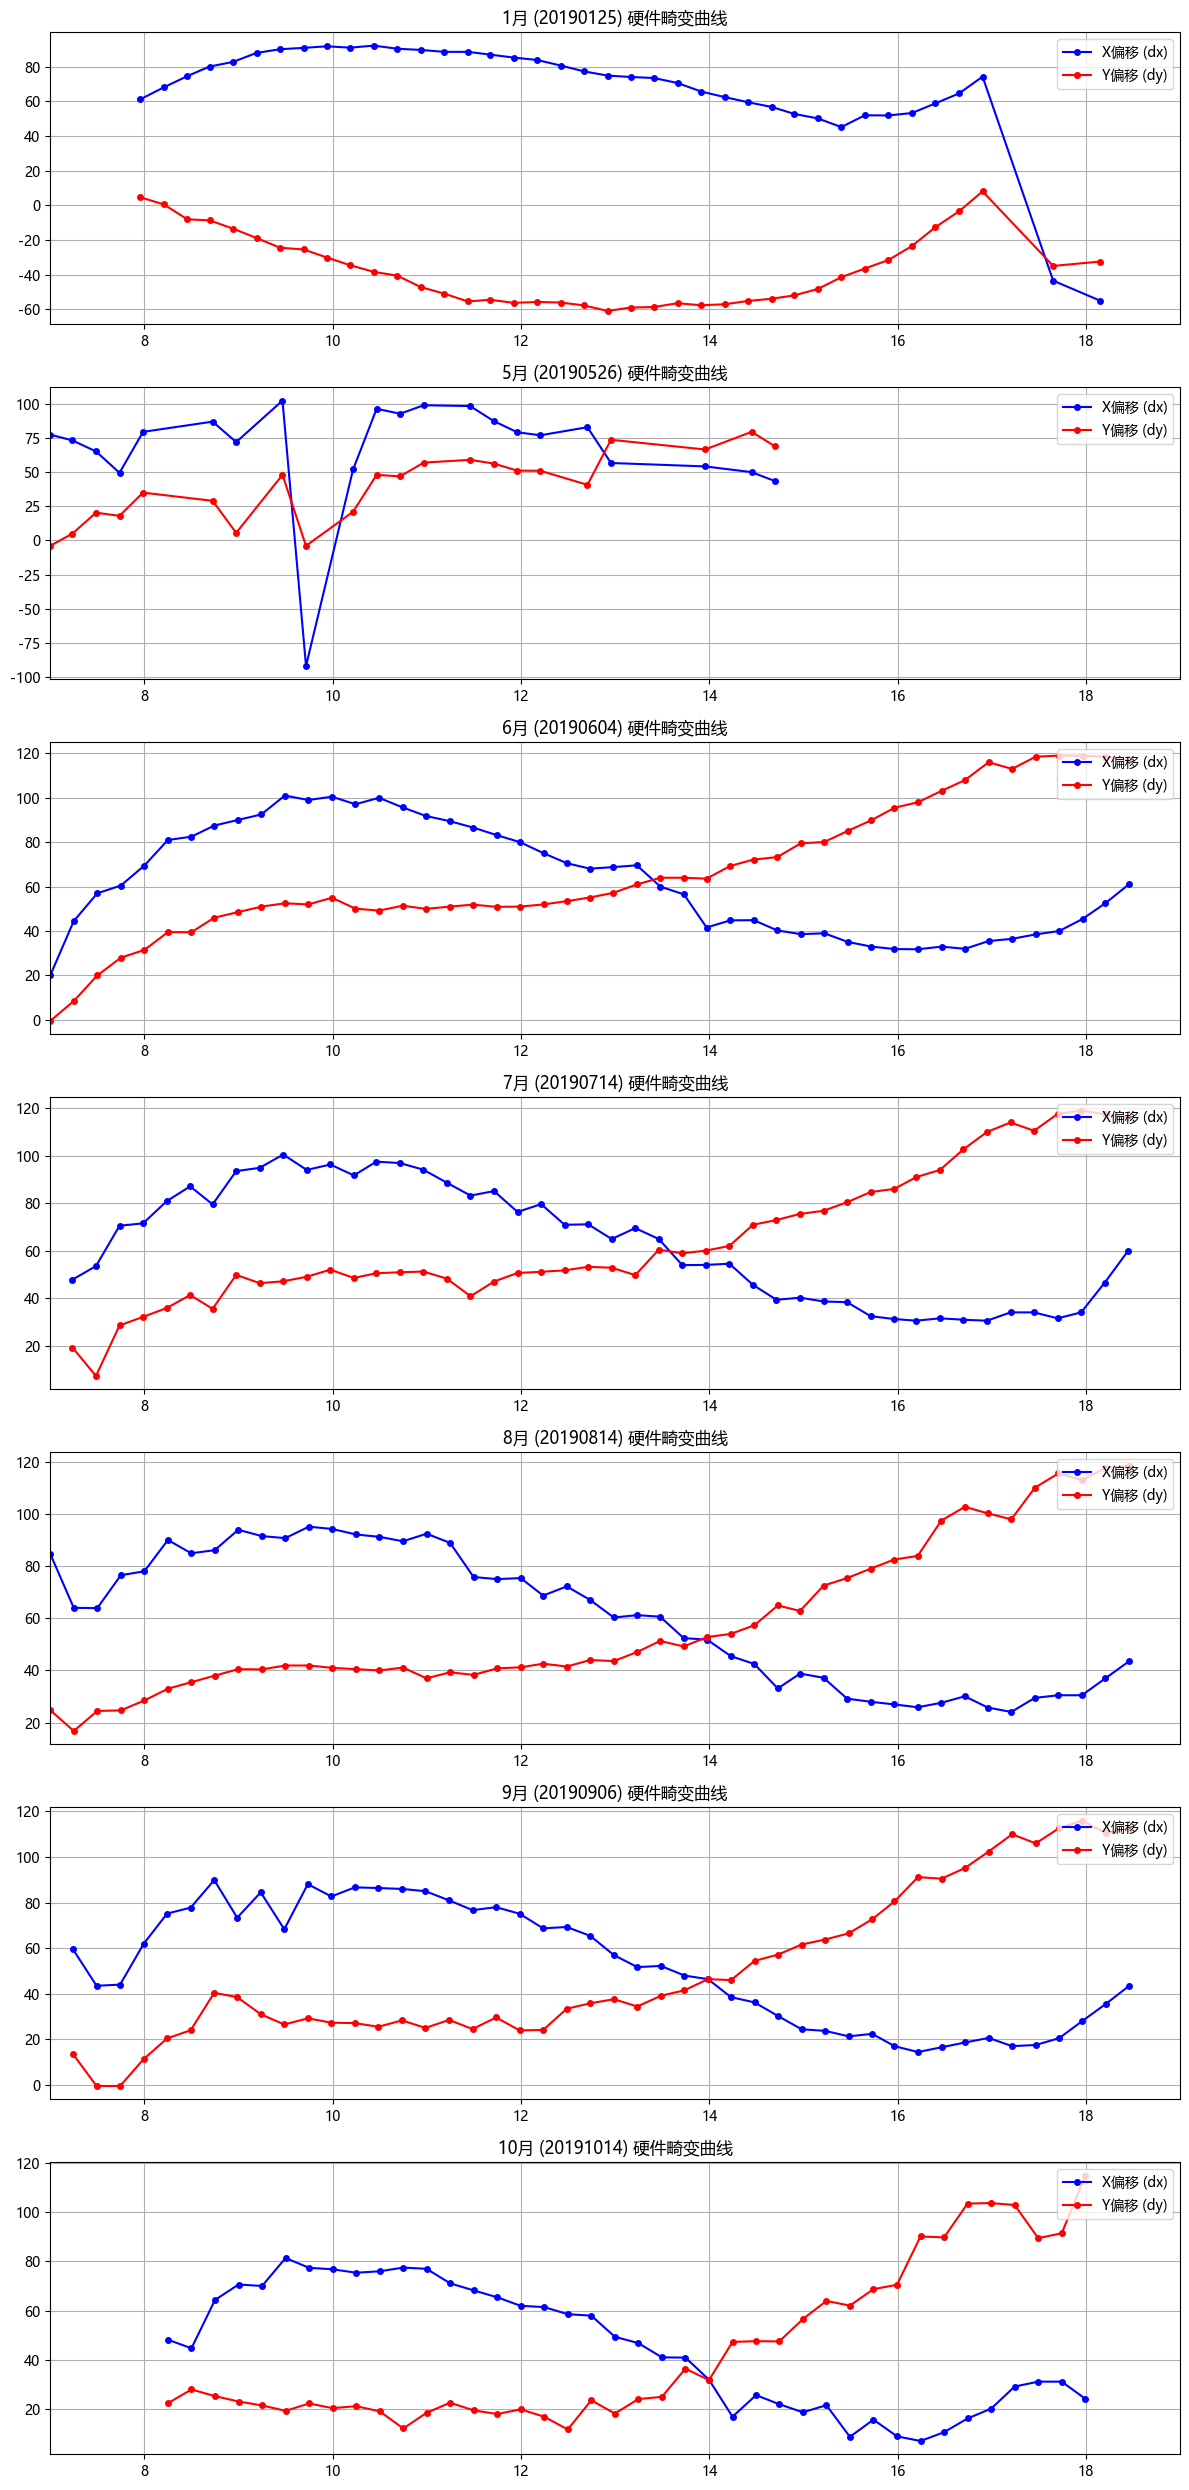


时序插值台账提取完毕！将下方输出复制保存：

MONTHLY_INTERP_TABLE = {
    1: {
        'times': [7.956, 8.206, 8.456, 8.692, 8.942, 9.192, 9.442, 9.692, 9.942, 10.186, 10.436, 10.686, 10.936, 11.186, 11.436, 11.672, 11.922, 12.172, 12.422, 12.672, 12.922, 13.164, 13.414, 13.664, 13.914, 14.164, 14.414, 14.664, 14.903, 15.153, 15.403, 15.653, 15.903, 16.153, 16.403, 16.653, 16.903, 17.653, 18.15],
        'dx': [61.1, 68.0, 74.5, 80.0, 82.7, 87.9, 90.0, 90.8, 91.7, 90.9, 92.1, 90.3, 89.6, 88.5, 88.5, 86.9, 85.2, 83.8, 80.6, 77.2, 74.8, 74.0, 73.4, 70.5, 65.6, 62.4, 59.4, 56.7, 52.7, 50.1, 45.1, 51.9, 51.8, 53.2, 58.8, 64.5, 74.2, -43.5, -55.0],
        'dy': [4.6, 0.5, -8.1, -8.7, -13.5, -18.9, -24.5, -25.5, -30.2, -34.6, -38.4, -40.6, -47.2, -51.0, -55.5, -54.5, -56.3, -55.8, -56.1, -57.8, -61.0, -59.0, -58.7, -56.5, -57.7, -57.1, -55.2, -53.9, -52.0, -48.3, -41.5, -36.5, -31.6, -23.5, -12.6, -3.5, 8.0, -35.0, -32.5]
    },
    5: {
        'times': [7.0, 7.236, 7.486, 7.736, 7.986, 8.725, 8.975, 9.467, 9.

In [67]:
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans'] 
plt.rcParams['axes.unicode_minus'] = False


# 1.  7 个晴天基准日 (代表 7 个月)
sunny_days = [
    "20190125", "20190526", "20190604", 
    "20190714", "20190814", "20190906", "20191014"
]

def get_theo_sun_position(time_obj):
    """最纯净的天文理论坐标"""
    delta = 14.036 
    r = 928         
    origin_y =928  
    origin_x =960  
    azimuth, zenith = solar_angle(time_obj) 
    rho = zenith / 90 * r 
    theta = azimuth - delta + 90 
    theo_y = origin_y - rho * sin(radians(theta))
    theo_x = origin_x + rho * cos(radians(theta))
    return int(round(theo_x)), int(round(theo_y))

# 用于存储终极插值台账
MONTHLY_INTERP_TABLE = {}

# 画图 7 个月的畸变
fig, axes = plt.subplots(7, 1, figsize=(12, 25))
print("批量提取全天候物理畸变曲线...\n")

for idx, target_date in enumerate(sunny_days):
    month_str = target_date[4:6]
    month_int = int(month_str)
    tar_name = f"2019_{month_str}_images_raw.tar"
    tar_path = os.path.join(tar_folder, tar_name)
    
    if not os.path.exists(tar_path):
        print(f"跳过 {target_date}，找不到对应的 tar 包")
        continue
        
    time_floats = []
    dx_list = []
    dy_list = []
    
    with tarfile.open(tar_path, "r") as tar:
        members = tar.getmembers()
        day_members = [m for m in members if m.name.endswith('.jpg') and target_date in m.name]
        day_members.sort(key=lambda x: os.path.basename(x.name))
        
        # 每隔 15 张图（约十来分钟）采样一次
        for m in day_members[::15]:
            filename = os.path.basename(m.name)
            curr_time = dt.datetime.strptime(filename.split('.')[0], '%Y%m%d%H%M%S')
            
            # 只截取白天 07:00 到 18:30 的数据
            if curr_time.hour < 7 or (curr_time.hour == 18 and curr_time.minute > 30) or curr_time.hour > 18:
                continue
                
            f = tar.extractfile(m)
            img_array = np.asarray(bytearray(f.read()), dtype=np.uint8)
            img_raw = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
            gray = cv2.cvtColor(img_raw, cv2.COLOR_BGR2GRAY)
            
            theo_x, theo_y = get_theo_sun_position(curr_time)
            
            # 局部视觉提取真实中心 (抗眩光版)
            search_radius = 120
            
            # 防止越界
            if theo_y - search_radius < 0 or theo_y + search_radius > 2048 or theo_x - search_radius < 0 or theo_x + search_radius > 2048:
                continue
                
            roi = gray[theo_y - search_radius : theo_y + search_radius, 
                       theo_x - search_radius : theo_x + search_radius]
            
            _, thresh = cv2.threshold(roi, 245, 255, cv2.THRESH_BINARY)
            kernel = np.ones((7, 7), np.uint8)
            eroded = cv2.erode(thresh, kernel, iterations=2)
            contours, _ = cv2.findContours(eroded, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
            
            if contours:
                largest_contour = max(contours, key=cv2.contourArea)
                # 过滤太小的噪点
                if cv2.contourArea(largest_contour) > 50:
                    (cX_local, cY_local), _ = cv2.minEnclosingCircle(largest_contour)
                    
                    real_x = theo_x - search_radius + cX_local
                    real_y = theo_y - search_radius + cY_local
                    
                    dx = real_x - theo_x
                    dy = real_y - theo_y
                    
                    time_float = curr_time.hour + curr_time.minute / 60.0 + curr_time.second / 3600.0
                    
                    time_floats.append(round(time_float, 3))
                    dx_list.append(round(dx, 1))
                    dy_list.append(round(dy, 1))
    
    # 存入字典
    if time_floats:
        MONTHLY_INTERP_TABLE[month_int] = {
            'times': time_floats,
            'dx': dx_list,
            'dy': dy_list
        }
        
        # 画出该月的曲线
        ax = axes[idx]
        ax.plot(time_floats, dx_list, 'b-o', label='X偏移 (dx)', markersize=4)
        ax.plot(time_floats, dy_list, 'r-o', label='Y偏移 (dy)', markersize=4)
        ax.set_title(f"{month_int}月 ({target_date}) 硬件畸变曲线")
        ax.set_xlim([7, 19])
        ax.grid(True)
        ax.legend(loc='upper right')
        print(f" {month_int}月台账提取成功！采样点数: {len(time_floats)}")

plt.tight_layout()
plt.show()

# 打印最终输出字典，方便复制
print("\n" + "="*60)
print("时序插值台账提取完毕！将下方输出复制保存：\n")
print("MONTHLY_INTERP_TABLE = {")
for m, data in MONTHLY_INTERP_TABLE.items():
    print(f"    {m}: {{")
    print(f"        'times': {data['times']},")
    print(f"        'dx': {data['dx']},")
    print(f"        'dy': {data['dy']}")
    print("    },")
print("}")
print("="*60)

### 使用生成的偏移台账，来矫正图像，看看效果如何。

正在从数据集中盲抽测试日期 (避开标定日)...
盲抽结果: ['20190127', '20190518', '20190627', '20190702', '20190817', '20190903', '20191018']
正在生成盲测拼图...


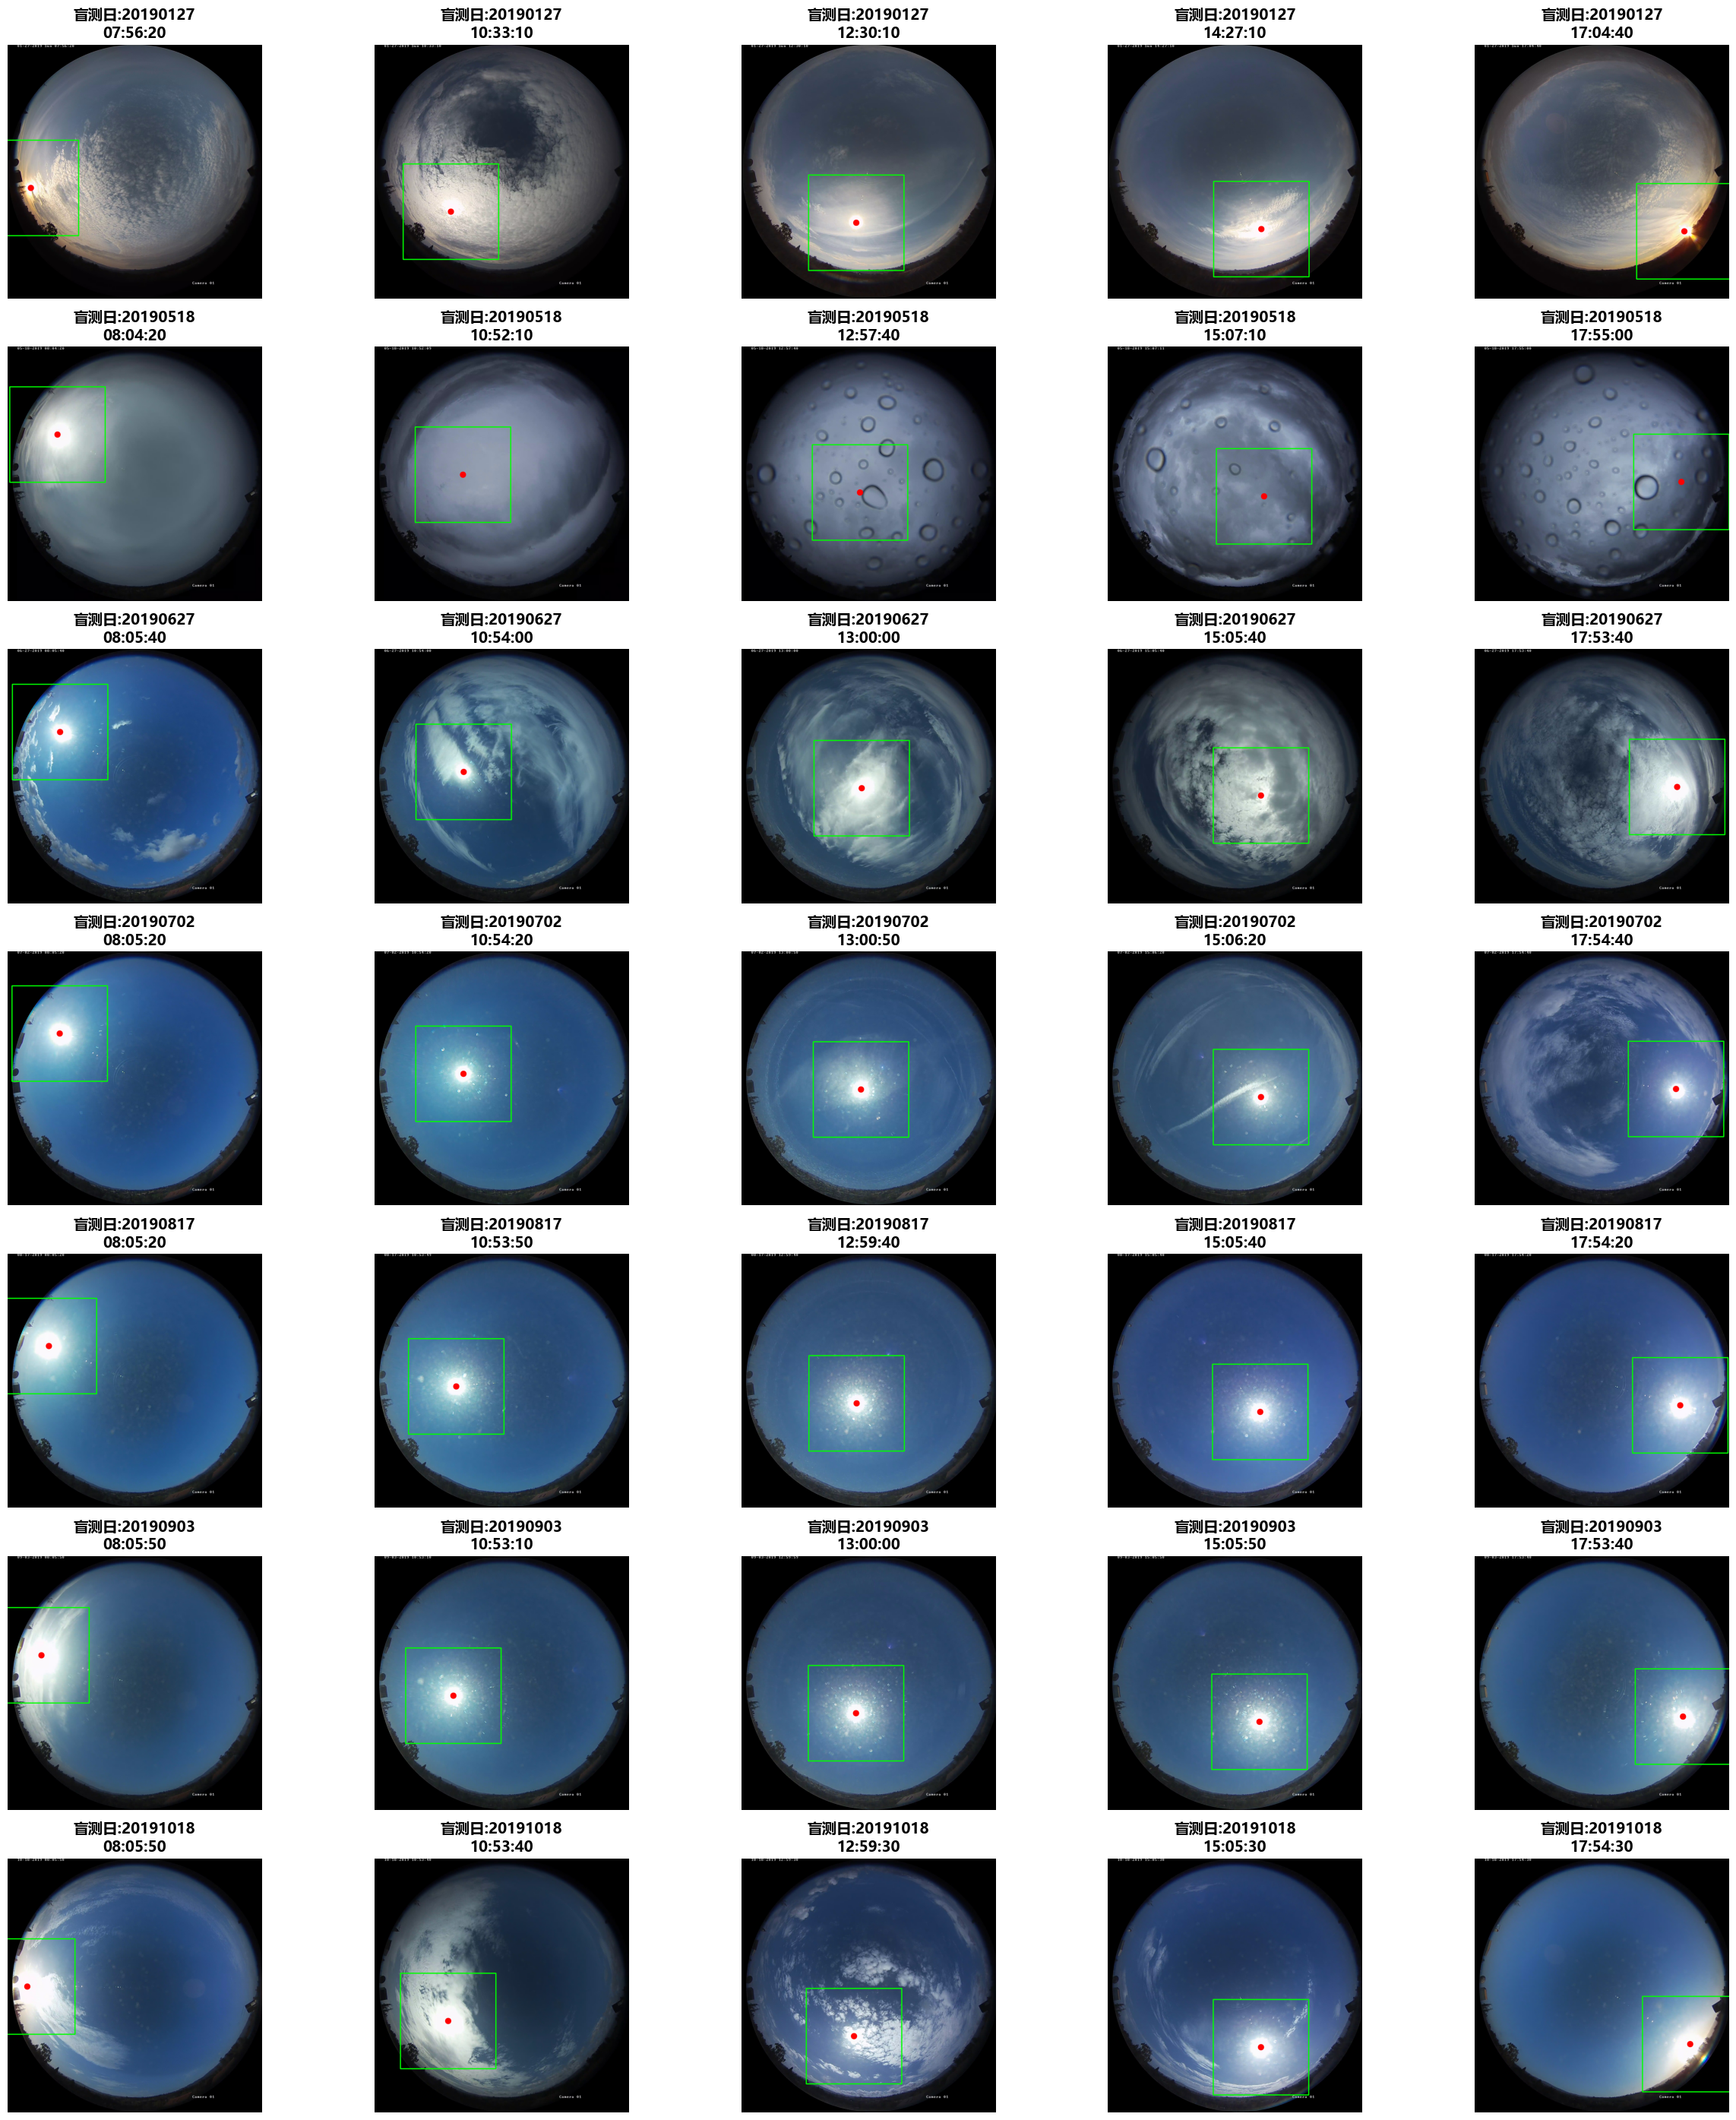

盲测拼图完成！


In [68]:
# =========================================
FALLBACK_MONTHS = { 2: 1, 3: 1, 4: 1, 11: 10, 12: 10 }

# ==========================================
# 2. 查表插值定位逻辑
# ==========================================
def get_smart_sun_position(time_obj):
    delta = 14.036 
    r = 928         
    origin_y =928  
    origin_x =960  
    azimuth, zenith = solar_angle(time_obj) 
    rho = zenith / 90 * r 
    theta = azimuth - delta + 90 
    theo_y = origin_y - rho * sin(radians(theta))
    theo_x = origin_x + rho * cos(radians(theta))
    
    month = time_obj.month
    ref_month = month if month in MONTHLY_INTERP_TABLE else FALLBACK_MONTHS[month]
    table = MONTHLY_INTERP_TABLE[ref_month]
    
    t_curr = time_obj.hour + time_obj.minute / 60.0 + time_obj.second / 3600.0
    dx = np.interp(t_curr, table['times'], table['dx'])
    dy = np.interp(t_curr, table['times'], table['dy'])
    
    return int(round(theo_x + dx)), int(round(theo_y + dy))

# ==========================================
# 3. 盲抽逻辑：每个月随机选一个未见过的新日期
# ==========================================
calibration_days = ["20190125", "20190526", "20190604", "20190714", "20190814", "20190906", "20191014"]
months_to_test = [1, 5, 6, 7, 8, 9, 10]
blind_test_days = []

print("正在从数据集中盲抽测试日期 (避开标定日)...")
for month in months_to_test:
    tar_name = f"2019_{month:02d}_images_raw.tar"
    tar_path = os.path.join(tar_folder, tar_name)
    if os.path.exists(tar_path):
        with tarfile.open(tar_path, "r") as tar:
            members = tar.getmembers()
            # 提取所有唯一的日期 (YYYYMMDD)
            all_days = list(set([os.path.basename(m.name)[:8] for m in members if m.name.endswith('.jpg')]))
            # 剔除掉标定用的那天
            valid_days = [d for d in all_days if d not in calibration_days]
            if valid_days:
                # 随机挑一天（这里也可以改为挑特定的某一天，比如 valid_days[0]）
                blind_test_days.append(random.choice(valid_days))

# 按月份排序一下，方便查看
blind_test_days.sort()
print(f"盲抽结果: {blind_test_days}")

# ==========================================
# 4. 开始画盲测拼图
# ==========================================
if not blind_test_days:
    print("没有找到可用的测试日期，请检查你的 tar 包路径。")
else:
    fig, axes = plt.subplots(len(blind_test_days), 5, figsize=(25, 4 * len(blind_test_days)))
    print("正在生成盲测拼图...")
    
    # 兼容只抽到一天导致 axes 不是二维数组的情况
    if len(blind_test_days) == 1:
        axes = np.array([axes])

    for row_idx, day_str in enumerate(blind_test_days):
        month_str = day_str[4:6]
        tar_name = f"2019_{month_str}_images_raw.tar"
        tar_path = os.path.join(tar_folder, tar_name)
        
        with tarfile.open(tar_path, "r") as tar:
            members = tar.getmembers()
            day_members = [m for m in members if m.name.endswith('.jpg') and day_str in m.name]
            day_members.sort(key=lambda x: os.path.basename(x.name))
            
            num_imgs = len(day_members)
            if num_imgs < 10: 
                print(f"{day_str} 数据太少，跳过画图")
                continue
                
            sample_indices = [int(num_imgs*0.15), int(num_imgs*0.35), int(num_imgs*0.50), int(num_imgs*0.65), int(num_imgs*0.85)]
            
            for col_idx, img_idx in enumerate(sample_indices):
                m = day_members[img_idx]
                filename = os.path.basename(m.name)
                curr_time = dt.datetime.strptime(filename.split('.')[0], '%Y%m%d%H%M%S')
                
                f = tar.extractfile(m)
                img_array = np.asarray(bytearray(f.read()), dtype=np.uint8)
                img_raw = cv2.imdecode(img_array, cv2.IMREAD_COLOR)
                img_rgb = cv2.cvtColor(img_raw, cv2.COLOR_BGR2RGB)
                
                sun_x, sun_y = get_smart_sun_position(curr_time)
                
                HUGE_CROP_RADIUS = 384
                top_left = (sun_x - HUGE_CROP_RADIUS, sun_y - HUGE_CROP_RADIUS)
                bottom_right = (sun_x + HUGE_CROP_RADIUS, sun_y + HUGE_CROP_RADIUS)
                
                cv2.rectangle(img_rgb, top_left, bottom_right, (0, 255, 0), 8) 
                cv2.circle(img_rgb, (sun_x, sun_y), 25, (255, 0, 0), -1)       
                
                ax = axes[row_idx, col_idx]
                ax.imshow(img_rgb)
                ax.set_title(f"盲测日:{day_str}\n{curr_time.strftime('%H:%M:%S')}", fontsize=14, weight='bold')
                ax.axis('off')

    plt.tight_layout()
    plt.show()
    print("盲测拼图完成！")